In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "True"
os.environ["JAX_DEFAULT_DTYPE_BITS"] = "64"

import time
import jax
import jax.numpy as jnp
from jax import jit, random, jvp
import optax
from flax import linen as nn
from flax.training import train_state
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
jax.config.update('jax_enable_x64', True)
ic_lambda = 20.

In [2]:
class TINN(nn.Module):
    t_layers: list
    layers: list
    @nn.compact
    def __call__(self, xt):
        xt = jnp.asarray(xt)
        is_scalar = (xt.ndim == 1)
        if is_scalar:
            xt = xt.reshape(1,2)
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        # time encoder
        temp_t = t
        for i in range(len(self.t_layers)-2):
            tW = self.param(f"tW{i}", nn.initializers.xavier_uniform(), (self.t_layers[i], self.t_layers[i+1]))
            tb = self.param(f"tb{i}", nn.initializers.zeros, (self.t_layers[i+1],))
            temp_t = jnp.tanh(jnp.matmul(temp_t, tW) + tb)
        tWout = self.param("tWout", nn.initializers.xavier_uniform(), (self.t_layers[-2], self.t_layers[-1]))
        temp_t = jnp.matmul(temp_t, tWout)
        t_alpha = self.param("t_alpha", nn.initializers.ones, (1, self.t_layers[-1]))
        temp_t = ((1.0 - t_alpha) * t) + (t_alpha * temp_t)
        # periodic embedding
        z = jnp.hstack([jnp.cos(jnp.pi*x), jnp.sin(jnp.pi*x)])
        for i in range(len(self.layers)-2):
            in_dim = self.layers[i]
            out_dim = self.layers[i+1]
            aW = self.param(f"aW{i}", nn.initializers.zeros, (in_dim, out_dim))
            ab = self.param(f"ab{i}", nn.initializers.xavier_uniform(), (1,out_dim))
            bW = self.param(f"bW{i}", nn.initializers.xavier_uniform(), (in_dim, out_dim))
            bb = self.param(f"bb{i}", nn.initializers.zeros, (out_dim,))
            coef = temp_t[..., 2*i:2*i+1]
            term1 = jnp.matmul(z, aW) * coef
            term2 = jnp.matmul(z, bW)
            coef = temp_t[..., 2*i+1:2*i+2]
            b_eff = ab * coef + bb
            z = jnp.tanh(term1 + term2 + b_eff)
        # output layer
        aW_out = self.param("aWout", nn.initializers.zeros, (self.layers[-2], self.layers[-1]))
        bW_out = self.param("bWout", nn.initializers.xavier_uniform(), (self.layers[-2], self.layers[-1]))
        coef_out = temp_t[..., -1:]
        term1 = jnp.matmul(z, aW_out) * coef_out
        term2 = jnp.matmul(z, bW_out)
        y = term1 + term2
        y = jnp.squeeze(y, axis=-1)
        if is_scalar:
            return y[0]
        return y

In [3]:
def ic_function(x):
    x = jnp.asarray(x).reshape(-1)
    return x**2 * jnp.cos(3*jnp.pi*x) + x**2

def make_jvp_kernels(model):
    def u_batch(params, xt_batch):
        return model.apply({'params': params}, xt_batch)
    @jax.jit
    def grads_jvp(params, xt_batch):
        N = xt_batch.shape[0]
        v_x = jnp.tile(jnp.array([1.0, 0.0]), (N,1))
        v_t = jnp.tile(jnp.array([0.0, 1.0]), (N,1))
        _, u_x = jvp(lambda xs: u_batch(params, xs), (xt_batch,), (v_x,))
        _, u_t = jvp(lambda xs: u_batch(params, xs), (xt_batch,), (v_t,))
        return u_x, u_t

    @jax.jit
    def u_xx_jvp(params, xt_batch):
        N = xt_batch.shape[0]
        v_x = jnp.tile(jnp.array([1.0, 0.0]), (N,1))
        def first_tangent(xs):
            _, tangent = jvp(lambda x_in: u_batch(params, x_in), (xs,), (v_x,))
            return tangent
        _, u_xx = jvp(first_tangent, (xt_batch,), (v_x,))
        return u_xx
    u_batch_jit = jax.jit(u_batch)
    return u_batch_jit, grads_jvp, u_xx_jvp

def build_loss_and_steps(model):
    u_batch, grads_jvp, u_xx_jvp = make_jvp_kernels(model)
    @jax.jit
    def pde_residual_single(params, xt):
        u = u_batch(params, xt[None, :])[0]
        u_x, u_t = grads_jvp(params, xt[None, :])
        u_xx = u_xx_jvp(params, xt[None, :])
        return u_t -0.0001*u_xx + 5*u**3 - 5*u
    pde_jac_single = jax.jacrev(pde_residual_single, argnums=0)
    ic_jac_single  = jax.jacrev(lambda p, xt: ic_lambda*(u_batch(p, xt[None,:])[0] - ic_function(xt[0])), argnums=0)
    
    def vmap_jac(jac_single, xt_batch, params, chunk=15000):
        N = xt_batch.shape[0]
        outs = []
        for i in range(0, N, chunk):
            xt_sub = xt_batch[i:i+chunk]
            jac_sub = jax.vmap(lambda xt: jac_single(params, xt))(xt_sub)
            outs.append(jac_sub)
        return jax.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *outs)
    
    @jax.jit
    def loss_fn(params, batch_coll_xt, batch_ic_xt):
        res_pde = jax.vmap(lambda xt: pde_residual_single(params, xt))(batch_coll_xt)
        res_ic = jax.vmap(
            lambda xt: ic_lambda*(u_batch(params, xt[None,:])[0] - ic_function(xt[0])))(batch_ic_xt)
        lpde = jnp.mean(res_pde**2)
        lic = jnp.mean(res_ic**2)
        total = lpde+lic
        return total, (lpde, lic)
    
    @jax.jit
    def train_step(params, batch_coll_xt, batch_ic_xt):
        res_pde = jax.vmap(lambda xt: pde_residual_single(params, xt))(batch_coll_xt)
        res_ic = jax.vmap(
            lambda xt: ic_lambda*(u_batch(params, xt[None,:])[0] - ic_function(xt[0])))(batch_ic_xt)
        pde_theta = vmap_jac(pde_jac_single, batch_coll_xt, params)
        ic_theta  = vmap_jac(ic_jac_single,  batch_ic_xt, params)
        return res_pde, pde_theta, res_ic, ic_theta
    return loss_fn, train_step

In [4]:
def sample_collocation(rng, N):
    k1, k2 = random.split(rng)
    x = random.uniform(k1, (N,1), minval=-1.0, maxval=1.0)
    t = 1*random.uniform(k2, (N,1), minval=0.0, maxval=1.0)
    return jnp.hstack([x,t])

def sample_ic(rng, N):
    x = random.uniform(rng, (N,1), minval=-1.0, maxval=1.0)
    t = jnp.zeros_like(x)
    return jnp.hstack([x,t])

In [5]:
data = scipy.io.loadmat('new_AC.mat')
Exact = data["u_ref"]
t = data["t_data"].flatten()
x = data["x_data"].flatten()
TT, XX = jnp.meshgrid(t, x, indexing="ij")
total_test = len(TT.flatten())
def L2Error():
    u_pred = jax.vmap(model.apply, (None, 0))({'params': params}, jnp.hstack((XX.reshape([total_test,1]), TT.reshape([total_test,1])))).reshape(TT.shape)
    error = Exact-u_pred
    # l2 error
    l2_error = np.sqrt(np.sum(error.flatten()**2)/total_test)
    rel_l2_error = l2_error / np.sqrt(np.sum(Exact.flatten()**2)/total_test)
    return rel_l2_error

In [6]:
key = random.PRNGKey(4)
model = TINN([1,10,10,5], [2,20,20,1])
xt_dummy = jnp.zeros((1,2))
params = model.init(key, xt_dummy)['params']
total_number = 0
for p in params:
    total_number +=params[p].size
print("total parameter:", total_number)

loss_fn, train_step = build_loss_and_steps(model)
_dummy_coll = sample_collocation(key, 8)
_dummy_ic = sample_ic(key, 4)
_ = loss_fn(params, _dummy_coll, _dummy_ic)
res_pde, pde_theta, res_ic, ic_theta = train_step(params, _dummy_coll, _dummy_ic)

N_coll = 10000
N_ic   = 500
N_val_coll = 5000
N_val_ic = 250
key, kc, ki = random.split(key, 3)
batch_coll_xt = sample_collocation(kc, N_coll)
batch_ic_xt   = sample_ic(ki, N_ic)
key, vk1, vk2 = random.split(key, 3)
val_coll_xt = sample_collocation(vk1, N_val_coll)
val_ic_xt   = sample_ic(vk2, N_val_ic)
# ic_average = jnp.mean(jnp.sort(abs(ic_function(batch_ic_xt[:,0])))[:300])
# print(1/(ic_average))

def LM_reshape(grad_params):
    N_num = grad_params['aW0'].shape[0]
    temp = grad_params['aW0'].reshape(N_num, jnp.size(grad_params['aW0'])//N_num)
    for ii, p in enumerate(grad_params):
        if ii>0:
            temp = jnp.hstack((temp, grad_params[p].reshape(N_num, jnp.size(grad_params[p])//N_num )))
    return temp
#------------------------------
Epoch = 30000
mu = 10**1
itera_ = 0
mu_update = 2
div_factor = 1.3
mul_factor = 1.7
loss_sum_old = 10**5
min_mu = 10**-12
loss_LM = []
l2_error_list = []
#-------------------------------
start = time.time()
for step in range(Epoch):
    res_pde, pde_theta, res_ic, ic_theta = train_step(params, batch_coll_xt, batch_ic_xt)
    re_pde_theta = LM_reshape(pde_theta)
    re_ic_theta = LM_reshape(ic_theta)
    val_tot, (val_pde, val_ic) = loss_fn(params, val_coll_xt, val_ic_xt)
    
    # J_mat
    J_mat = jax.lax.concatenate((re_pde_theta/(N_coll**0.5), re_ic_theta/N_ic**0.5), 0)
    #L_vec
    L_vec = jax.lax.concatenate((res_pde/N_coll**0.5, res_ic/N_ic**0.5), 0)
    loss = jnp.mean(res_ic**2) + jnp.mean(res_pde**2)
    loss_LM.append(loss.item())
    
    # update lambda
    I = jnp.eye((J_mat.shape[1]))
    J_product = J_mat.T@J_mat
    rhs = -J_mat.T@L_vec
    dp = jnp.linalg.solve((J_product+mu*I) , rhs)
    cnt=0
    for p in pde_theta:
        num = jnp.size(params[p])
        params[p] = params[p] + dp[cnt:cnt+num].reshape(params[p].shape)
        cnt+=num
    itera_ += 1
    if step % mu_update == 0:
        if loss < loss_sum_old:
            mu = max(mu/div_factor, min_mu)
        else:
            mu = min(mul_factor*mu, 10**(8))
        loss_sum_old = loss
    if loss.item()/mu > 1*10**5:
        mu = loss.item()/10
    if step%50 == 0:
        lpde = jnp.mean(res_pde**2)
        lic = jnp.mean(res_ic**2)
        elapsed = time.time()-start
        temp_error = L2Error().item()
        l2_error_list.append(temp_error)
        print(f"Epoch {itera_:4d} | L2Error={temp_error:.3e} | loss={loss:.3e} | val={val_tot:.3e} | mu={mu:.3e} | pde={lpde:.3e} | ic={lic:.3e} | time={elapsed:.1f}s")
    
    if (val_tot/loss>5):
        print('Validation')
        key, kc, ki = random.split(key, 3)
        batch_coll_xt = sample_collocation(kc, N_coll)
        batch_ic_xt   = sample_ic(ki, N_ic)

print('the final Loss: %.5e'% (loss))
print('the final valid Loss: %.5e'% (val_tot))
final_time = time.time()
print('total time:', final_time - start)

total parameter: 1185


<ipython-input-3-1544174850c6>:49: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *outs)
<ipython-input-3-1544174850c6>:49: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *outs)
<ipython-input-3-1544174850c6>:49: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *outs)
<ipython-input-3-1544174850c6>:49: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *outs)


Epoch    1 | L2Error=6.864e-01 | loss=1.443e+02 | val=1.435e+02 | mu=7.692e+00 | pde=1.776e+00 | ic=1.425e+02 | time=4.3s
Epoch   51 | L2Error=2.673e-01 | loss=3.648e-03 | val=3.764e-03 | mu=1.090e-02 | pde=3.233e-03 | ic=4.149e-04 | time=9.5s
Epoch  101 | L2Error=7.145e-02 | loss=1.225e-04 | val=1.297e-04 | mu=8.144e-04 | pde=1.013e-04 | ic=2.117e-05 | time=14.0s
Epoch  151 | L2Error=3.215e-02 | loss=1.952e-05 | val=2.177e-05 | mu=1.345e-04 | pde=1.559e-05 | ic=3.930e-06 | time=18.6s
Epoch  201 | L2Error=7.259e-03 | loss=5.303e-06 | val=6.282e-06 | mu=4.907e-05 | pde=3.645e-06 | ic=1.658e-06 | time=23.1s


KeyboardInterrupt: 

In [7]:
data = scipy.io.loadmat('new_AC.mat')
Exact = data["u_ref"]
t = data["t_data"].flatten()
x = data["x_data"].flatten()
TT, XX = jnp.meshgrid(t, x, indexing="ij")
total_test = len(TT.flatten())
u_pred = jax.vmap(model.apply, (None, 0))({'params': params}, jnp.hstack((XX.reshape([total_test,1]), TT.reshape([total_test,1])))).reshape(TT.shape)
error = Exact-u_pred

# l2 error
l2_error = np.sqrt(np.sum(error.flatten()**2)/total_test)
l_int_error = np.max(abs(error.flatten()))
rel_l2_error = l2_error / np.sqrt(np.sum(Exact.flatten()**2)/total_test)
rel_l_inf_error = l_int_error / np.max(abs(Exact.flatten()))

print('L2-Error:%.5e'%l2_error)
print('Linf-Error:%.5e'%l_int_error)
print('rel-L2-Error: %.5e'% rel_l2_error)
print('rel-Linf-Error: %.5e'% rel_l_inf_error)

L2-Error:3.74565e-03
Linf-Error:7.49303e-02
rel-L2-Error: 5.15354e-03
rel-Linf-Error: 7.49304e-02


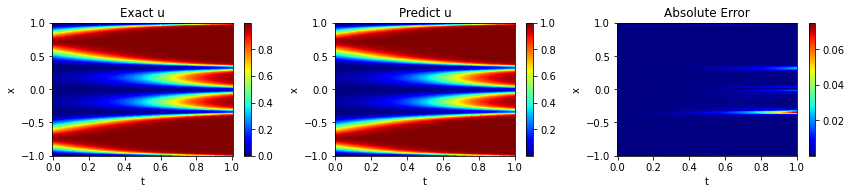

In [8]:
fig = plt.figure(figsize=(12,2.8))

plt.subplot(1,3,1)
plt.pcolor(TT, XX, Exact, cmap="jet")
plt.xlabel('t')
plt.ylabel('x')
plt.title('Exact u')
plt.colorbar()

plt.subplot(1,3,2)
plt.pcolor(TT, XX, u_pred, cmap="jet")
plt.xlabel('t')
plt.ylabel('x')
plt.title('Predict u')
plt.colorbar()

plt.subplot(1,3,3)
plt.pcolor(TT, XX, abs(error), cmap="jet")
plt.xlabel('t')
plt.ylabel('x')
plt.title('Absolute Error')
plt.colorbar()

plt.tight_layout()
#plt.savefig("TINN_AC.png", dpi=300)
plt.show()